In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/data.csv", encoding="ISO-8859-1")

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
clean_df = df.copy()


In [9]:
clean_df.shape


(541909, 8)

In [10]:
clean_df.drop_duplicates(inplace=True)

In [11]:
clean_df.shape


(536641, 8)

In [12]:
clean_df = clean_df.dropna(subset=["CustomerID"])

In [13]:
clean_df.shape

(401604, 8)

In [14]:
clean_df = clean_df.dropna(subset=["Description"])

In [15]:
clean_df.shape

(401604, 8)

In [16]:
clean_df = clean_df[~clean_df["InvoiceNo"].astype(str).str.startswith("C")]


In [17]:
clean_df = clean_df[clean_df["Quantity"] > 0]

In [18]:
clean_df = clean_df[clean_df["UnitPrice"] > 0]

In [19]:
clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"])

In [20]:
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]

In [21]:
clean_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [22]:
total_revenue = clean_df["Revenue"].sum()

print(f"Total Revenue : ${total_revenue:,.2f}")

Total Revenue : $8,887,208.89


In [23]:
clean_df["InvoiceNo"].nunique()

18532

In [24]:
clean_df["CustomerID"].nunique()

4338

In [25]:
total_quantity = clean_df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 5152002


In [27]:
total_orders = clean_df["InvoiceNo"].nunique()

print("Total Orders:", total_orders)

Total Orders: 18532


In [28]:
average_order_value = total_revenue / total_orders

print(f"Average Order Value: ${average_order_value:,.2f}")

Average Order Value: $479.56


In [29]:
clean_df["Month"] = clean_df["InvoiceDate"].dt.to_period("M")

In [30]:
monthly_sales = clean_df.groupby("Month")["Revenue"].sum()

monthly_sales

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64

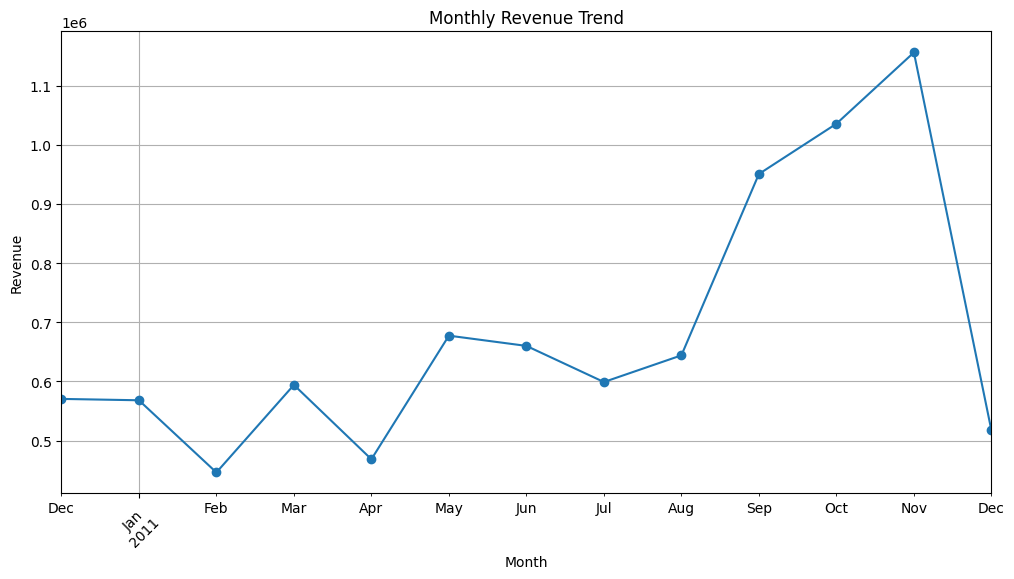

In [31]:
plt.figure(figsize=(12,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

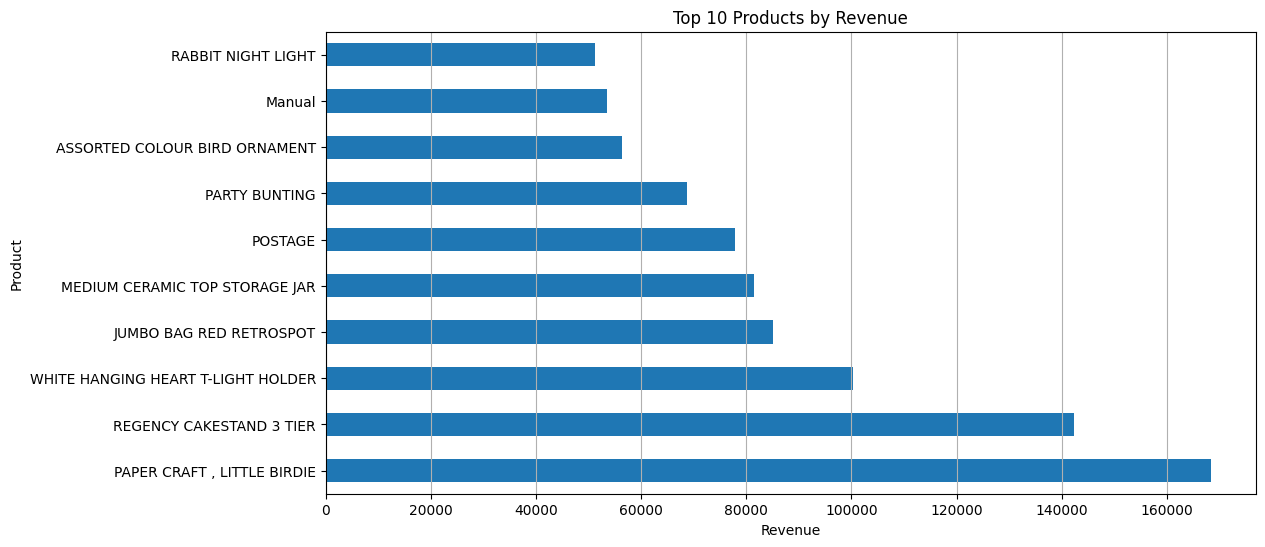

In [34]:
top_products = (
    clean_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))

top_products.plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.grid(axis="x")

plt.show()

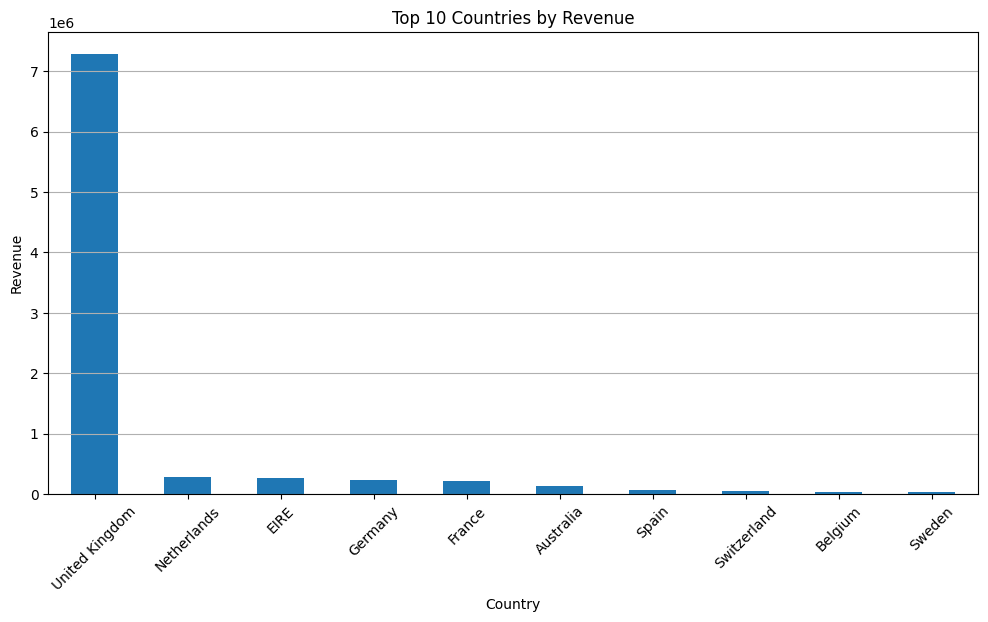

In [35]:
country_sales = (
    clean_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

plt.figure(figsize=(12,6))

country_sales.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

In [36]:
clean_df.to_csv("../data/Cleaned_Ecommerce.csv", index=False)